In [17]:
#!pip install ultralytics opencv-python pandas scikit-learn matplotlib

In [3]:
import torch
import cv2
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from pathlib import Path
import shutil
from matplotlib.patches import Patch


print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.9.0+cu126
CUDA available: True


In [7]:
csv_path = 'data.csv'
df = pd.read_csv(csv_path, header=None, names=['image_name', 'class', 'x1', 'y1', 'x2', 'y2'])

In [8]:
# YOLO dataset
yolo_dataset_dir = "yolo_dataset"
shutil.rmtree(yolo_dataset_dir, ignore_errors=True)

os.makedirs(f"{yolo_dataset_dir}/train/images", exist_ok=True)
os.makedirs(f"{yolo_dataset_dir}/train/labels", exist_ok=True)
os.makedirs(f"{yolo_dataset_dir}/val/images", exist_ok=True)
os.makedirs(f"{yolo_dataset_dir}/val/labels", exist_ok=True)

In [9]:
# Split train/val 80/20
unique_images = df['image_name'].unique()
train_images, val_images = train_test_split(unique_images, test_size=0.2, random_state=42)

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")

Training images: 291
Validation images: 73


In [ ]:
class_mapping = {'WBC': 0, 'RBC': 1, 'Platelets': 2}
images = 'images'

def convert_to_yolo_format(image_names, split_type):
    for image_name in image_names:
        src_image_path = os.path.join(images, image_name)
        dst_image_path = f"{yolo_dataset_dir}/{split_type}/images/{image_name}"
        shutil.copy2(src_image_path, dst_image_path)

        # Image Dimensions
        img = cv2.imread(src_image_path)
        if img is None:
            continue

        img_height, img_width = img.shape[:2]

        # Box plots for this image
        image_data = df[df['image_name'] == image_name]
        label_lines = []

        for _, row in image_data.iterrows():
            class_id = class_mapping[row['class']]
            x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']

            # Convert to YOLO
            x_center = ((x1 + x2) / 2) / img_width
            y_center = ((y1 + y2) / 2) / img_height
            width = (x2 - x1) / img_width
            height = (y2 - y1) / img_height

            x_center = max(0, min(1, x_center))
            y_center = max(0, min(1, y_center))
            width = max(0, min(1, width))
            height = max(0, min(1, height))

            label_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        # Labels
        label_filename = os.path.splitext(image_name)[0] + '.txt'
        with open(f"{yolo_dataset_dir}/{split_type}/labels/{label_filename}", 'w') as f:
            f.write('\n'.join(label_lines))

convert_to_yolo_format(train_images, 'train')
convert_to_yolo_format(val_images, 'val')

In [11]:
dataset_yaml = {
    'path': os.path.abspath(yolo_dataset_dir),
    'train': 'train/images',
    'val': 'val/images',
    'nc': 3,
    'names': ['WBC', 'RBC', 'Platelets']
}

with open('blood_cell_dataset.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

In [12]:
model = YOLO('yolov8n.pt')

training_results = model.train(
    data='blood_cell_dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.0001,
    patience=15,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    project='yolov8_results',
    name='blood_cell_detection',
    save=True,
    exist_ok=True
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=blood_cell_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=blood_cell_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, plots=True,

In [16]:
best_model = YOLO('yolov8_results/blood_cell_detection/weights/best.pt')
best_model.val()

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 683.9±179.0 MB/s, size: 20.3 KB)
val: Scanning /content/yolo_dataset/val/labels.cache... 73 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 73/73 112.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9it/s 2.6s
                   all         73       1038      0.856      0.918      0.927      0.641
                   WBC         72         74      0.973          1      0.995      0.822
                   RBC         70        864      0.787      0.815      0.865      0.606
             Platelets         49        100      0.807       0.94      0.922      0.495
Speed: 3.7ms preprocess, 4.0ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to /content/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7df09734e150>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

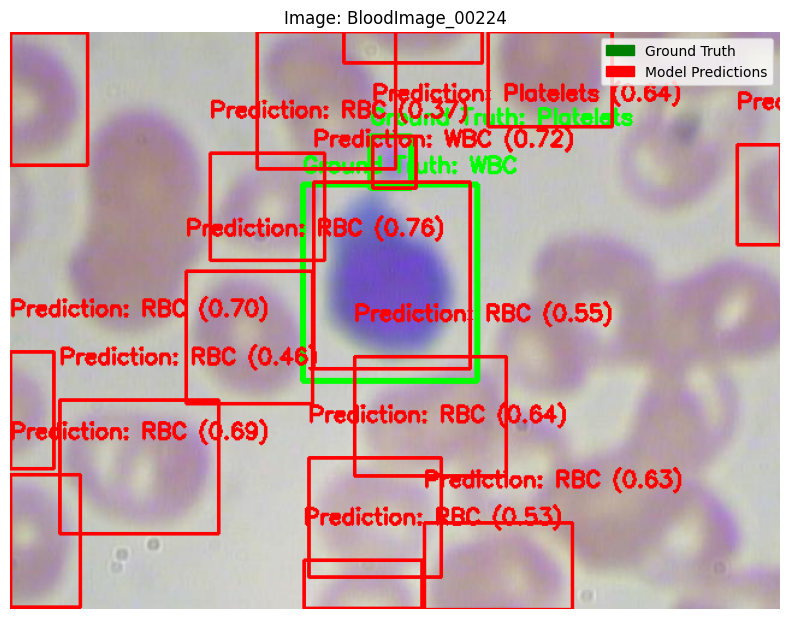

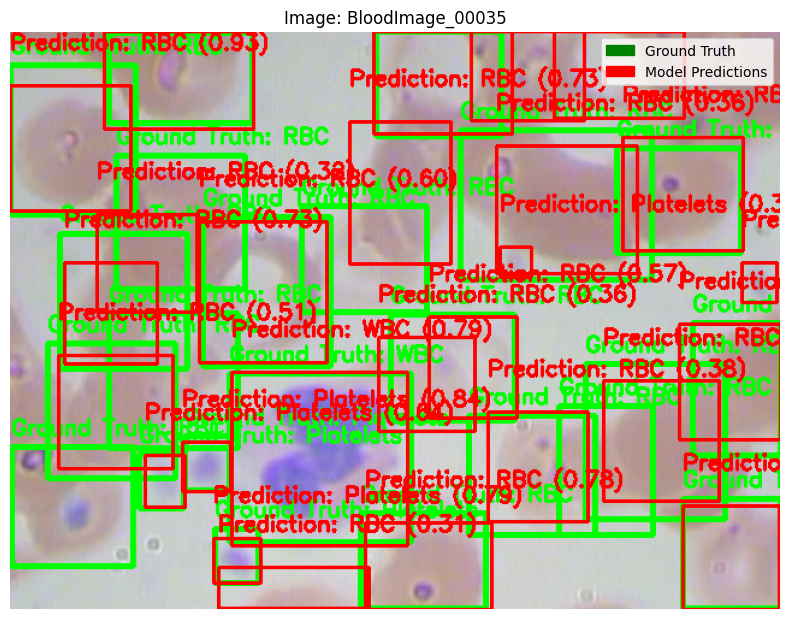

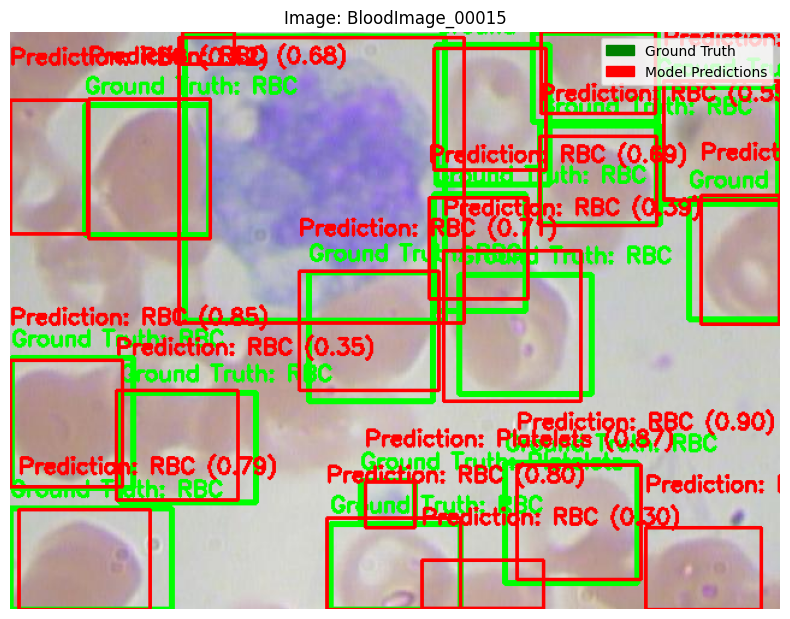

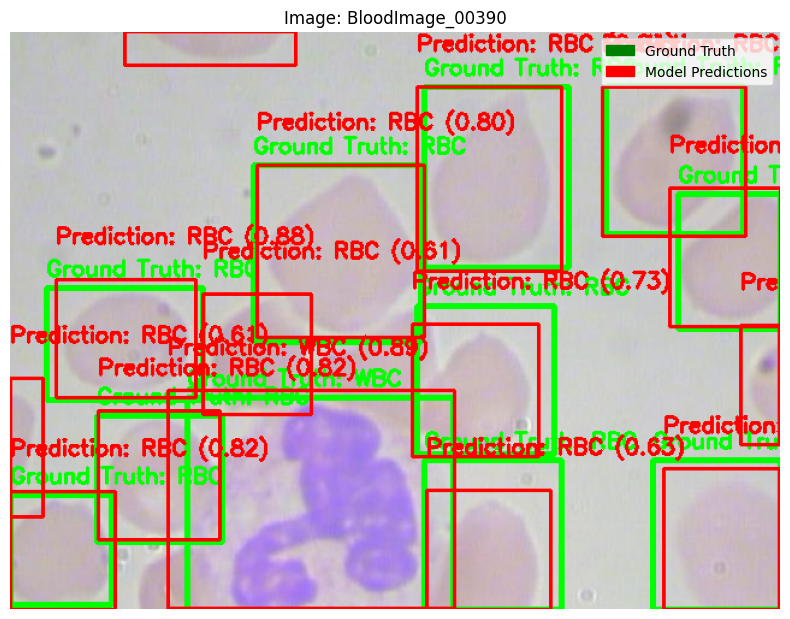

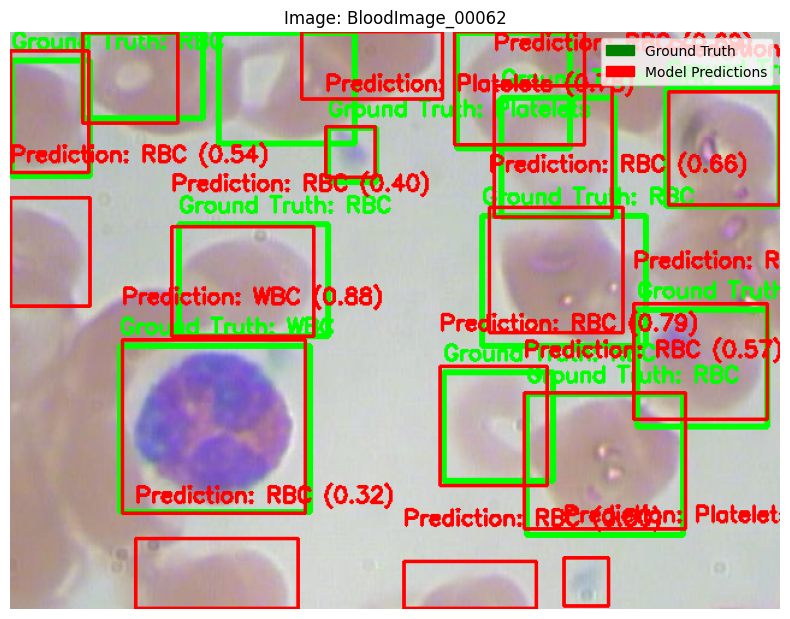

In [14]:
# Test Predictions
test_images = val_images[:5]

for i, image_filename in enumerate(test_images):
    image_filepath = f"{yolo_dataset_dir}/val/images/{image_filename}"
    label_filepath = f"{yolo_dataset_dir}/val/labels/{os.path.splitext(image_filename)[0]}.txt"

    # Load and prepare the image
    original_image = cv2.imread(image_filepath)
    display_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    overlay_image = display_image.copy()
    figure, axes = plt.subplots(1, 1, figsize=(8, 8))
    image_name = os.path.splitext(image_filename)[0]

    # Ground truth (Green)
    if os.path.exists(label_filepath):
        with open(label_filepath, 'r') as label_file:
            ground_truth_lines = label_file.readlines()

        for annotation_line in ground_truth_lines:
            annotation_parts = annotation_line.strip().split()

            if len(annotation_parts) >= 5:
                class_id = int(annotation_parts[0])
                x_center, y_center, width, height = map(float, annotation_parts[1:5])

                # YOLO format to pixel coordinates
                image_height, image_width = original_image.shape[:2]
                x1 = int((x_center - width/2) * image_width)
                y1 = int((y_center - height/2) * image_height)
                x2 = int((x_center + width/2) * image_width)
                y2 = int((y_center + height/2) * image_height)
                cv2.rectangle(overlay_image, (x1, y1), (x2, y2), (0, 255, 0), 3)
                class_name = dataset_yaml['names'][class_id]
                cv2.putText(overlay_image, f'Ground Truth: {class_name}',
                           (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                           0.6, (0, 255, 0), 2)

    # Predictions (Red)
    prediction_results = best_model.predict(
        source=image_filepath,
        conf=0.3,
        save=False,
        verbose=False
    )

    for result in prediction_results:
        if result.boxes is not None:
            for bounding_box in result.boxes:
                x1, y1, x2, y2 = bounding_box.xyxy[0].cpu().numpy().astype(int)
                confidence_score = float(bounding_box.conf[0])
                predicted_class_id = int(bounding_box.cls[0])

                cv2.rectangle(overlay_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

                predicted_class_name = dataset_yaml['names'][predicted_class_id]
                prediction_label = f"Prediction: {predicted_class_name} ({confidence_score:.2f})"
                cv2.putText(overlay_image, prediction_label, (x1, y1 - 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    axes.imshow(overlay_image)
    axes.set_title(f'Image: {image_name}')
    axes.axis('off')

    legend_items = [
        Patch(facecolor='green', edgecolor='green', label='Ground Truth'),
        Patch(facecolor='red', edgecolor='red', label='Model Predictions')
    ]
    axes.legend(handles=legend_items, loc='upper right')

    plt.tight_layout()
    plt.show()

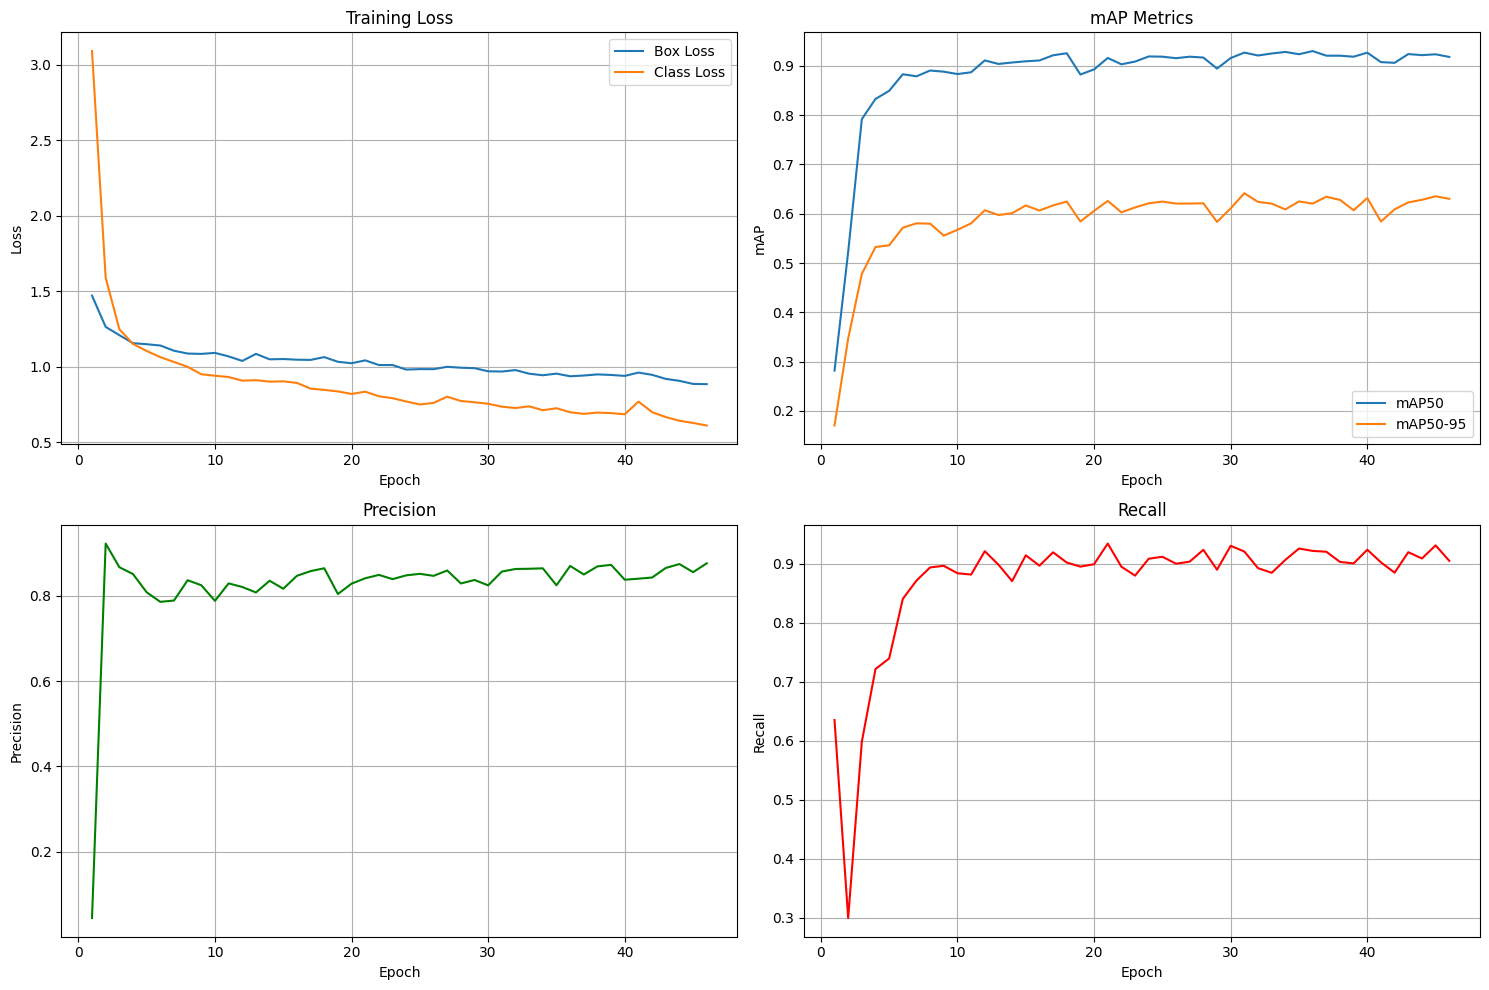

In [15]:
results_png = 'yolov8_results/blood_cell_detection/results.png'
results_csv = 'yolov8_results/blood_cell_detection/results.csv'
if os.path.exists(results_csv):
    results_df = pd.read_csv(results_csv)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Training
    axes[0,0].plot(results_df['epoch'], results_df['train/box_loss'], label='Box Loss')
    axes[0,0].plot(results_df['epoch'], results_df['train/cls_loss'], label='Class Loss')
    axes[0,0].set_title('Training Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # Validation
    axes[0,1].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP50')
    axes[0,1].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP50-95')
    axes[0,1].set_title('mAP Metrics')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision and Recall
    axes[1,0].plot(results_df['epoch'], results_df['metrics/precision(B)'], label='Precision', color='green')
    axes[1,0].set_title('Precision')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Precision')
    axes[1,0].grid(True)

    axes[1,1].plot(results_df['epoch'], results_df['metrics/recall(B)'], label='Recall', color='red')
    axes[1,1].set_title('Recall')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Recall')
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()